# MA9–MA20 Walk-Forward Trading Strategy

This strategy uses one EGX asset, starts with 1,000 EGP, buys when MA9 is above MA20, sells when MA9 is below MA20, uses all available cash when buying, does not use leverage or short selling, assumes no commissions or transaction costs, uses whole shares only, and uses only information available before the execution day.

In [1]:
import sys, os

while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')

sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed

feed = DataFeed.from_dir('data/egx')

In [2]:
# Select one asset to analyse.
symbol_position = 0

dates = feed.dates
close = feed.close[:, symbol_position]
symbol = feed.symbols[symbol_position]

print('Selected symbol:', symbol)
print('Historical days:', len(dates))

Selected symbol: ABUK
Historical days: 1159


In [3]:
# Create arrays for the moving averages with the same length as the price series.
ma9 = np.full(len(close), np.nan)
ma20 = np.full(len(close), np.nan)

# Walk forward through the price history and compute the moving averages
# using only information available up to the current day.
for i in range(len(close)):
    if i >= 8:
        ma9[i] = close[i - 8:i + 1].mean()
    if i >= 19:
        ma20[i] = close[i - 19:i + 1].mean()

In [5]:
# Walk-forward backtest using the previous day's moving-average signal.
initial_cash = 1000.0
cash = initial_cash
shares = 0
in_position = False

portfolio_values = np.zeros(len(close))
cash_history = np.zeros(len(close))
shares_history = np.zeros(len(close))

buy_dates = []
buy_prices = []
sell_dates = []
sell_prices = []

number_of_buys = 0
number_of_sells = 0

for i in range(len(close)):
    current_price = close[i]

    # Use the previous day's signal so the decision is not based on future data.
    if i > 0 and not np.isnan(ma9[i - 1]) and not np.isnan(ma20[i - 1]):
        if ma9[i - 1] > ma20[i - 1] and not in_position:
            shares_to_buy = int(cash // current_price)
            if shares_to_buy > 0:
                cash -= shares_to_buy * current_price
                shares = shares_to_buy
                buy_dates.append(dates[i])
                buy_prices.append(current_price)
                number_of_buys += 1
                in_position = True
        elif ma9[i - 1] < ma20[i - 1] and in_position:
            cash += shares * current_price
            sell_dates.append(dates[i])
            sell_prices.append(current_price)
            number_of_sells += 1
            shares = 0
            in_position = False

    portfolio_value = cash + shares * current_price
    portfolio_values[i] = portfolio_value
    cash_history[i] = cash
    shares_history[i] = shares

final_portfolio_value = portfolio_values[-1]
final_cash = cash
final_shares = shares

In [6]:
# Maximum drawdown using a simple walk-forward loop.
max_drawdown_egp = 0.0
max_drawdown_pct = 0.0

running_peak = initial_cash

for value in portfolio_values:
    if value > running_peak:
        running_peak = value

    drawdown_egp = running_peak - value
    if drawdown_egp > max_drawdown_egp:
        max_drawdown_egp = drawdown_egp
        if running_peak > 0:
            max_drawdown_pct = drawdown_egp / running_peak
        else:
            max_drawdown_pct = 0.0

In [7]:
# Basic validation checks.
assert len(ma9) == len(close)
assert len(ma20) == len(close)
assert len(portfolio_values) == len(close)
assert final_portfolio_value >= -1e-9, 'Portfolio value should not be negative.'
assert abs(number_of_buys - number_of_sells) <= 1, 'Buy/sell counts differ by more than one.'
assert np.all(shares_history >= -1e-9), 'Shares should never be negative.'
assert np.all(cash_history >= -1e-9), 'Cash should never be negative.'

In [8]:
# Report the results in a clear summary.
profit_loss = final_portfolio_value - initial_cash
total_return_percentage = (profit_loss / initial_cash) * 100

print('Strategy: MA9–MA20 crossover')
print('Asset symbol:', symbol)
print('Initial portfolio value:', round(initial_cash, 2))
print('Final portfolio value:', round(final_portfolio_value, 2))
print('Total profit/loss (EGP):', round(profit_loss, 2))
print('Total return (%):', round(total_return_percentage, 2))
print('Maximum drawdown (EGP):', round(max_drawdown_egp, 2))
print('Maximum drawdown (%):', round(max_drawdown_pct * 100, 2))
print('Number of buy operations:', number_of_buys)
print('Number of sell operations:', number_of_sells)
print('Final cash balance:', round(final_cash, 2))
print('Final shares held:', int(final_shares))

Strategy: MA9–MA20 crossover
Asset symbol: ABUK
Initial portfolio value: 1000.0
Final portfolio value: 3813.11
Total profit/loss (EGP): 2813.11
Total return (%): 281.31
Maximum drawdown (EGP): 1502.2
Maximum drawdown (%): 39.97
Number of buy operations: 33
Number of sell operations: 32
Final cash balance: 17.11
Final shares held: 52


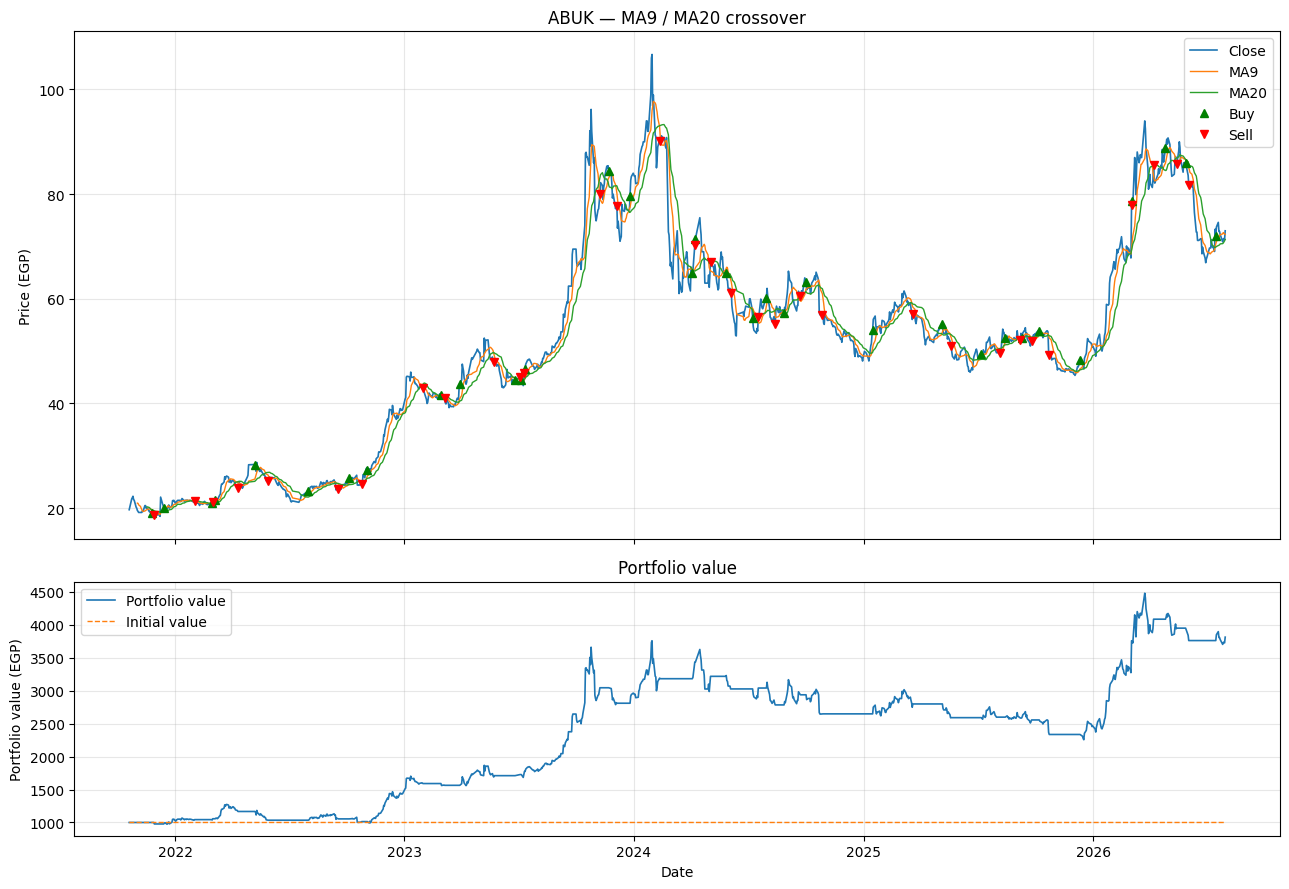

In [9]:
# Create a chart showing price, moving averages, trades, and portfolio value.
fig, (ax_price, ax_portfolio) = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

ax_price.plot(dates, close, label='Close', linewidth=1.2)
ax_price.plot(dates, ma9, label='MA9', linewidth=1.0)
ax_price.plot(dates, ma20, label='MA20', linewidth=1.0)

if buy_dates:
    ax_price.plot(buy_dates, buy_prices, marker='^', linestyle='None', color='green', label='Buy')
if sell_dates:
    ax_price.plot(sell_dates, sell_prices, marker='v', linestyle='None', color='red', label='Sell')

ax_price.set_title(f'{symbol} — MA9 / MA20 crossover')
ax_price.set_ylabel('Price (EGP)')
ax_price.legend()
ax_price.grid(alpha=0.3)

ax_portfolio.plot(dates, portfolio_values, label='Portfolio value', linewidth=1.2)
ax_portfolio.plot(dates, np.full(len(dates), initial_cash), label='Initial value', linestyle='--', linewidth=1.0)
ax_portfolio.set_title('Portfolio value')
ax_portfolio.set_ylabel('Portfolio value (EGP)')
ax_portfolio.set_xlabel('Date')
ax_portfolio.legend()
ax_portfolio.grid(alpha=0.3)

fig.tight_layout()
plt.show()